Exercise 3


In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import sklearn as sk
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from astropy.visualization import SimpleNorm


In [2]:
#load in the data
CLASS_NAMES = [
    'Disturbed', 'Merging', 'Round Smooth', 'In-between Smooth',
    'Cigar Smooth', 'Barred Spiral', 'Unbarred Tight Spiral',
    'Unbarred Loose Spiral', 'Edge-on no Bulge', 'Edge-on with Bulge']

with h5py.File('Galaxy10_DECals_64x64.h5', 'r') as F:
    images = np.array(F['images']) #shape(17736,64,64,3)
    labels = np.array(F['ans']) #integer class labels 0..9


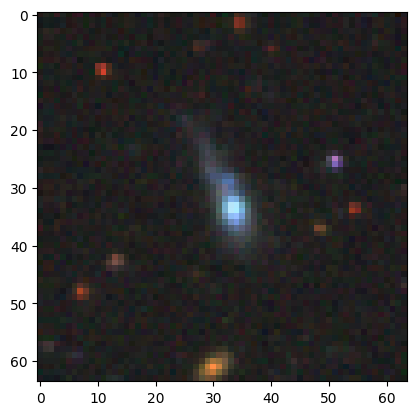

In [3]:
plt.imshow(images[27]/255.)

Task 1 - Exploration and preprocessing

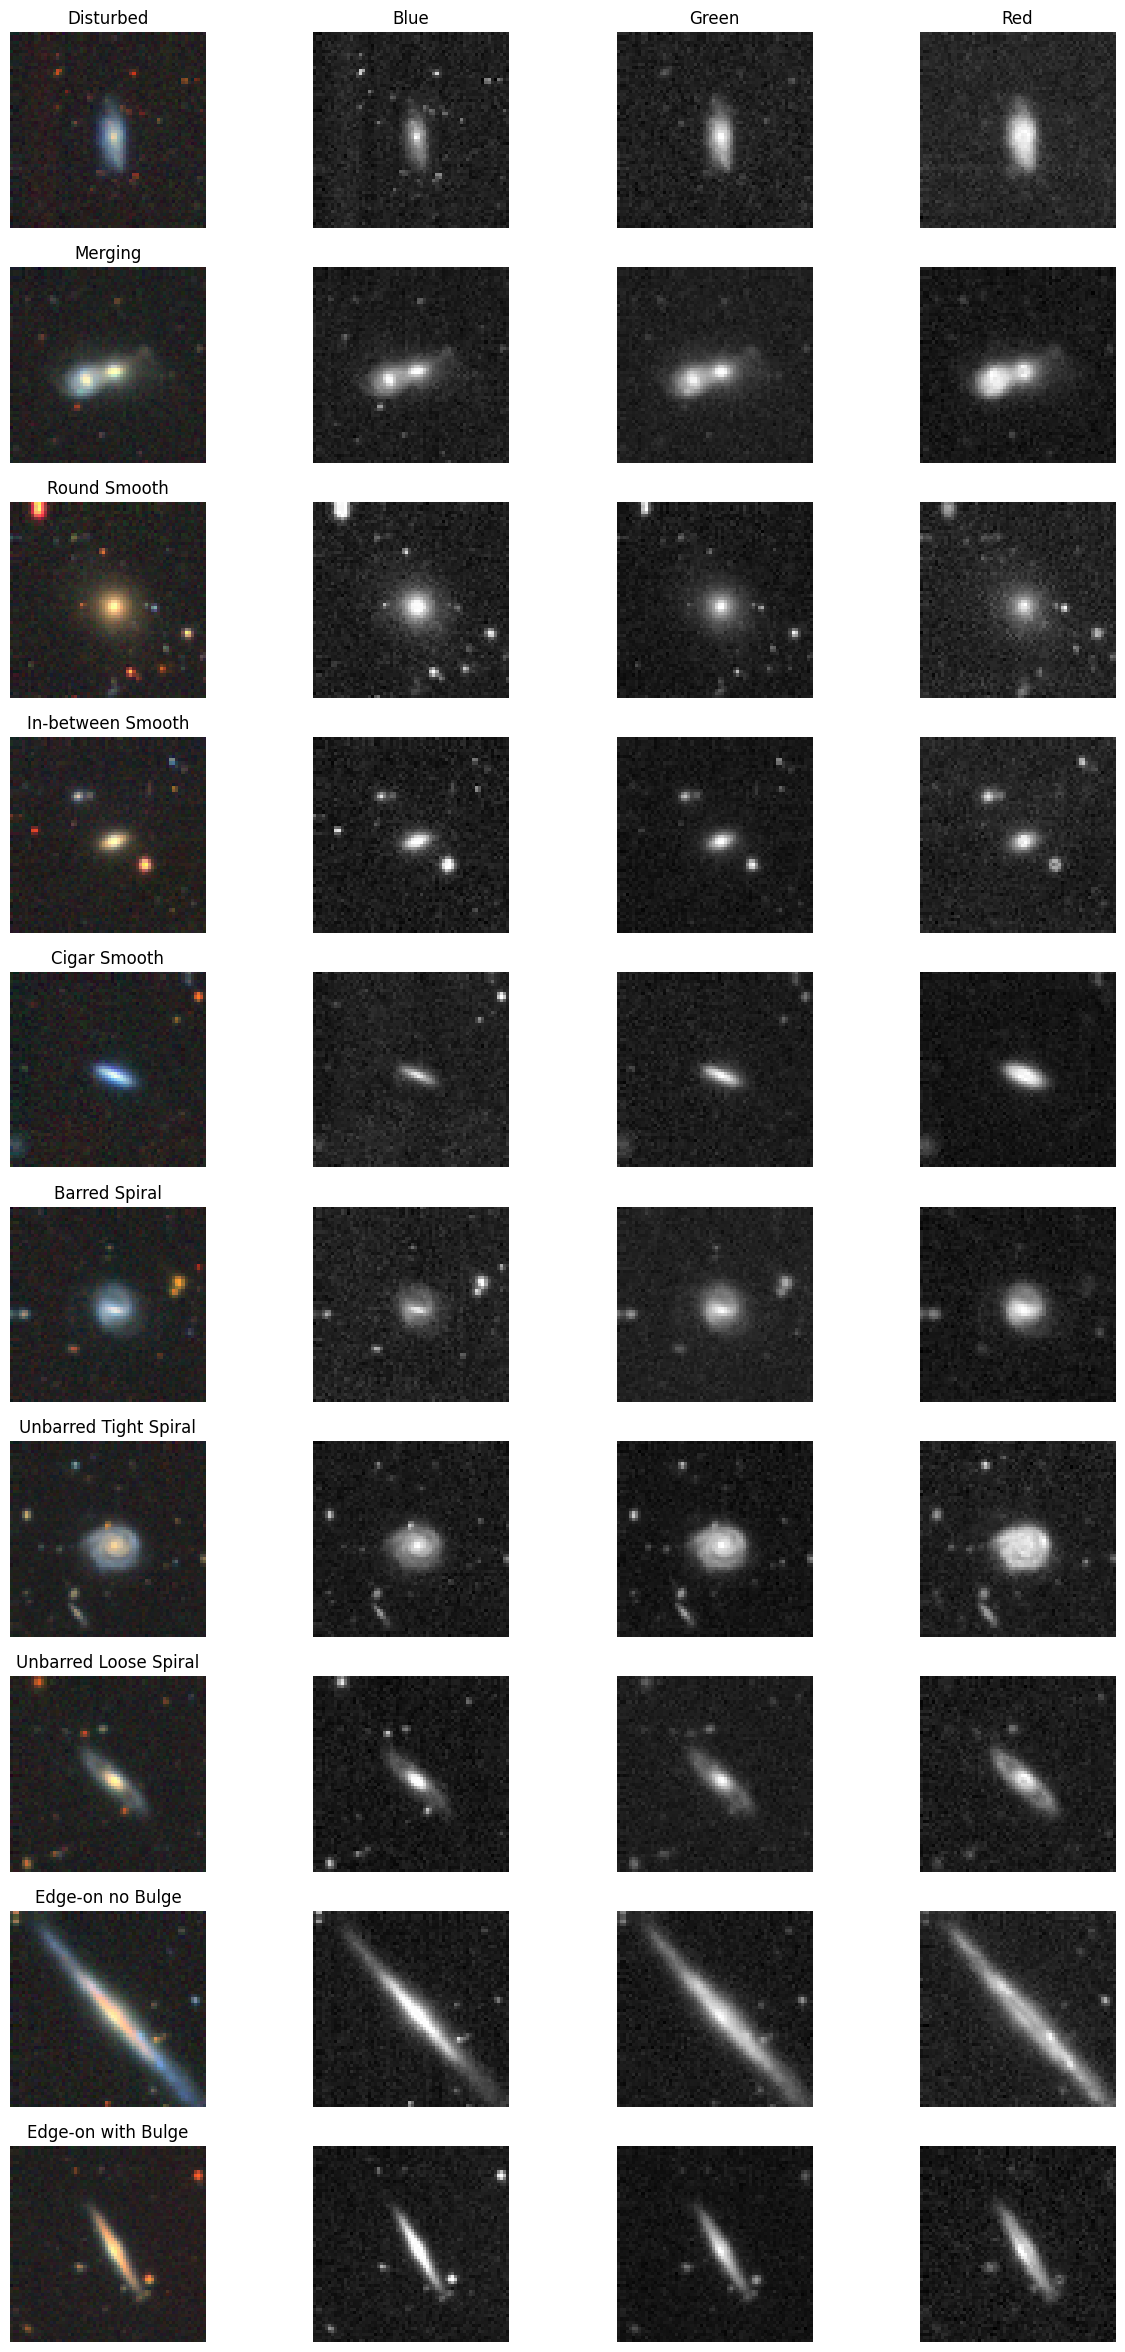

In [4]:
#plotting examples in RGB and individual bands
fig, axes = plt.subplots(10, 4, figsize=(15, 30))
band_names = ['RGB', 'Blue', 'Green', 'Red']

for c in range(10):
    idx = np.where(labels == c)[0]
    i = np.random.default_rng(0).choice(idx)
    axes[c, 0].imshow(images[i]/255.)
    axes[c, 0].set_title(CLASS_NAMES[c])

    for band in range(3):
        axes[c, band+1].imshow(images[i,:,:,band]/255., cmap='gray')
    for j in range(4):
        axes[c, j].axis('off')
        if c==0 and j != 0:
          axes[c, j].set_title(band_names[j])


In [5]:

gray = images.mean(axis=-1)
x = gray[56]


Task 2 - Plot the Single Value Decomposition (SVD) of a single Galaxy

In [6]:
U, S, Vt = np.linalg.svd(x, full_matrices=False)
def reconstruct(U, S, Vt, r):
  U_r = U[:,:r]
  S_r = np.diag(S[:r])
  Vt_r = Vt[:r, :]
  return U_r @ S_r @ Vt_r


Text(0.5, 1.0, '1/16')

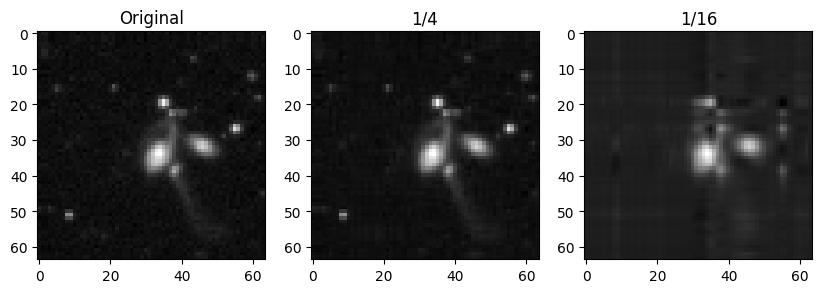

In [7]:
x_4 = reconstruct(U, S, Vt, 16)
x_16 = reconstruct(U, S, Vt, 4)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(x, cmap='gray')
axes[1].imshow(x_4, cmap='gray')
axes[2].imshow(x_16, cmap='gray')
axes[0].set_title('Original')
axes[1].set_title('1/4')
axes[2].set_title('1/16')


In [8]:

fve = np.cumsum(S**2) / np.sum(S**2)
r90 = np.argmax(fve>= 0.90) + 1
r99 = np.argmax(fve>= 0.99) + 1

print(r90)
print(r99)
print(fve)

2
9
[0.85979482 0.92751429 0.95062977 0.96475921 0.97590791 0.98365632
 0.98722572 0.98906372 0.99079056 0.99202665 0.99306141 0.99400245
 0.9947495  0.99527542 0.99572075 0.99610984 0.99643802 0.99672671
 0.99699408 0.99723107 0.99745177 0.99766052 0.99785802 0.99803733
 0.99819756 0.99835389 0.99850385 0.99864258 0.99877105 0.9988908
 0.99900981 0.99911404 0.99920545 0.99928621 0.99936015 0.9994291
 0.99949368 0.99955416 0.99960595 0.99965527 0.99970043 0.99973969
 0.99977463 0.9998049  0.9998341  0.99985786 0.9998812  0.99990159
 0.99991976 0.99993625 0.99995023 0.99996282 0.99997331 0.99998215
 0.99998814 0.99999236 0.9999957  0.99999723 0.99999852 0.99999924
 0.99999958 0.99999986 0.99999998 1.        ]


Text(0.5, 1.0, '8')

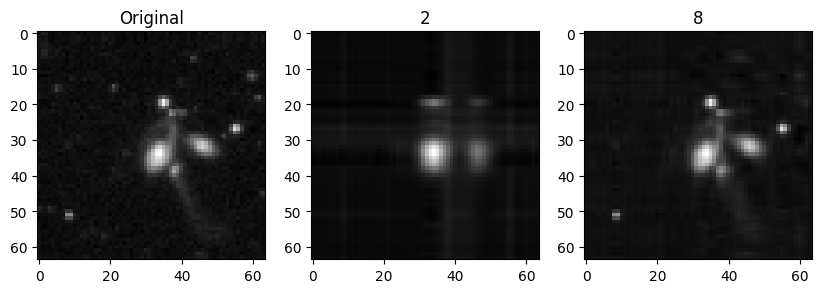

In [9]:
x_2 = reconstruct(U, S, Vt, 2)
x_8 = reconstruct(U, S, Vt, 8)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(x, cmap='gray')
axes[1].imshow(x_2, cmap='gray')
axes[2].imshow(x_8, cmap='gray')
axes[0].set_title('Original')
axes[1].set_title('2')
axes[2].set_title('8')


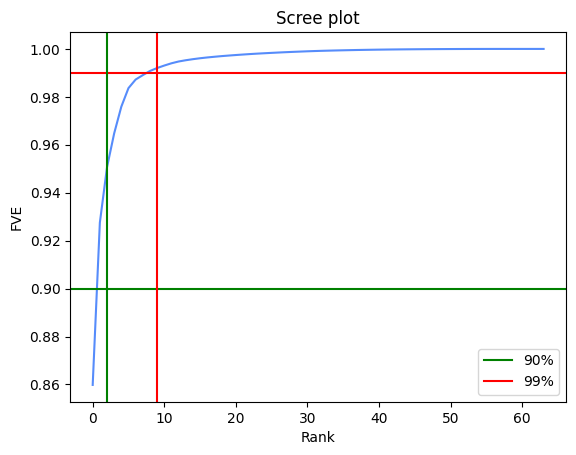

In [10]:
plt.plot(fve)
plt.axhline(0.90, color='g', label=f'90%')
plt.axhline(0.99, color='r', label=f'99%')
plt.axvline(r90, color='g')
plt.axvline(r99, color='r')
plt.xlabel('Rank')
plt.ylabel('FVE')
plt.title('Scree plot')
plt.legend()

In [11]:

n, m = x.shape
beta = min(n,m) / max(n,m)
omega = 0.56*beta**3 - 0.95*beta**2 + 1.82*beta + 1.43
tau = omega * np.median(S)
r_thr = int(np.sum(S > tau))
print(x.shape)
print(r_thr)


(64, 64)
12


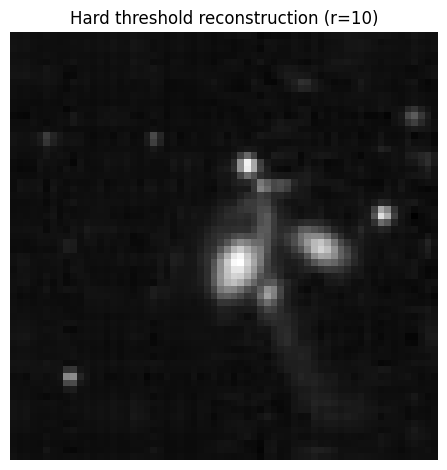

In [12]:

X_thr = reconstruct(U, S, Vt, r_thr)
plt.figure()
plt.imshow(X_thr, cmap='gray')
plt.title(r'Hard threshold reconstruction (r=10)')
plt.axis('off')
plt.tight_layout()


## Task 3 - SVD over the full galaxy sample

In [13]:
N = gray.shape[0]
x = gray.reshape(N,-1).T
xmean = x.mean(axis=1, keepdims=True)
x2 = x - xmean
U, S, Vt = sk.utils.extmath.randomized_svd(x2, n_components = 64)

In [14]:

fve_all = np.cumsum(S**2) / np.sum(S**2)
r90_all = np.argmax(fve_all >= 0.90) + 1
r99_all = np.argmax(fve_all >= 0.99) + 1

print(fve_all)

[0.43009826 0.50402482 0.57439758 0.62790308 0.6497187  0.67035735
 0.68937753 0.70785751 0.72526884 0.74247455 0.75934606 0.7706103
 0.78055467 0.79010167 0.798838   0.80727187 0.81524887 0.82278978
 0.8301483  0.83729828 0.84417643 0.8508812  0.85715079 0.86294389
 0.8684761  0.87370717 0.87876306 0.88374222 0.88852757 0.89324534
 0.8976349  0.90188036 0.90609734 0.91023448 0.91434585 0.91828421
 0.92213658 0.92590562 0.92966013 0.93325336 0.9366838  0.94009936
 0.94343579 0.94669934 0.94994832 0.9530331  0.95604945 0.95900963
 0.96194637 0.96487169 0.96765323 0.97041692 0.97312299 0.97579406
 0.97841558 0.98099239 0.98351213 0.98601034 0.98845153 0.99083361
 0.99318873 0.99549785 0.99775797 1.        ]


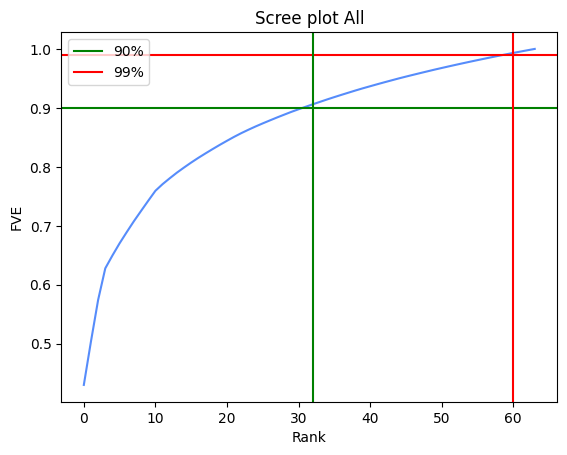

In [15]:
plt.plot(fve_all)
plt.axhline(0.90, color='g', label=f'90%')
plt.axhline(0.99, color='r', label=f'99%')
plt.axvline(r90_all, color='g')
plt.axvline(r99_all, color='r')
plt.xlabel('Rank')
plt.ylabel('FVE')
plt.title('Scree plot All')
plt.legend()

Eigenimages: Showing the first 6 right singular vectors reshaped back to image dimensions

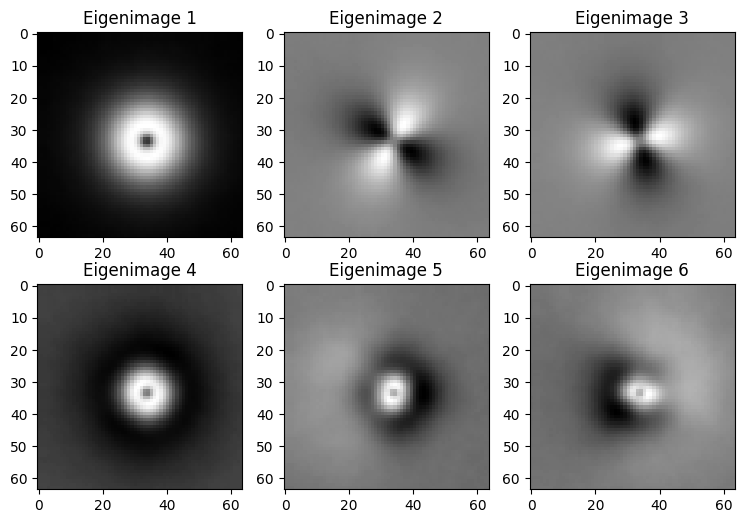

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for i, ax in enumerate(axes.flat):
  eigen = U[:,i].reshape(64,64)
  ax.imshow(eigen, cmap='gray')
  ax.set_title(f'Eigenimage {i+1}')



Morphology in PCA space: Projecting all galaxy images onto the plane spanned by the first two singular vectors and make a scatter plot coloured by morphological class label


In [17]:
pca = (x2).T @ U[:,:2]
pc1 = pca[:,0]
pc2 = pca[:,1]

Text(0.5, 1.0, 'Galaxy morphology in PCA space')

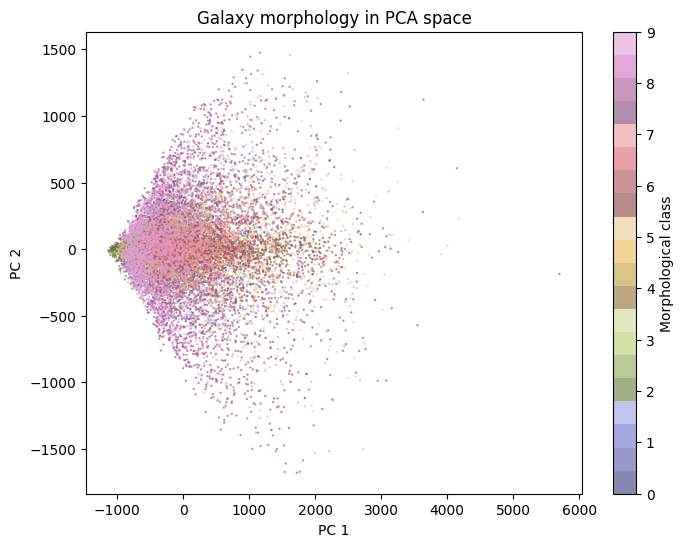

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(pc1, pc2, c=labels, cmap='tab20b', s=0.5, alpha=0.6)
plt.colorbar(scatter, label='Morphological class')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_title('Galaxy morphology in PCA space')


SVD latent traversal.


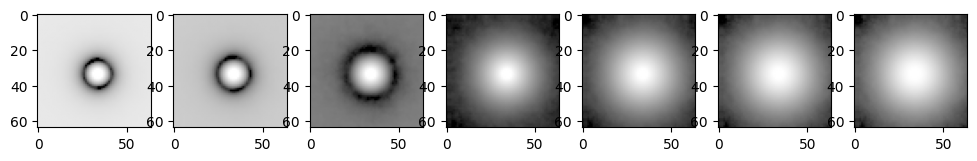

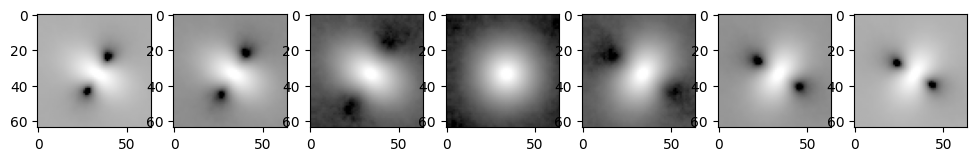

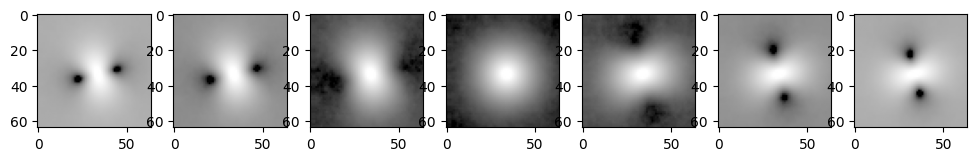

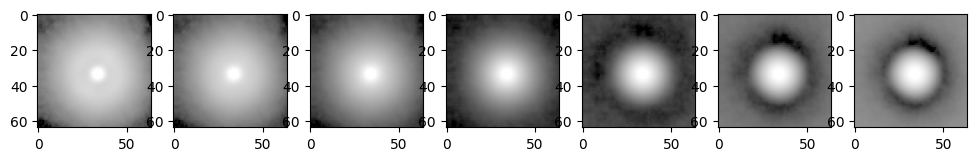

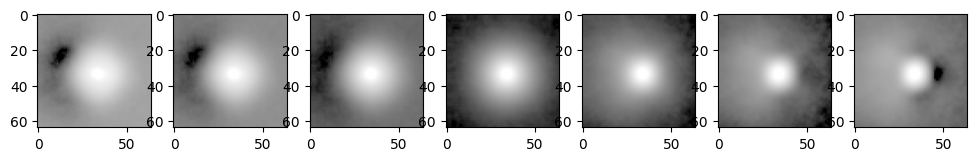

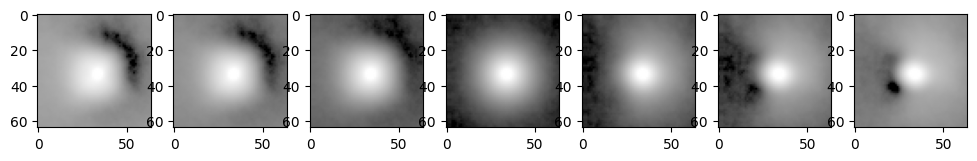

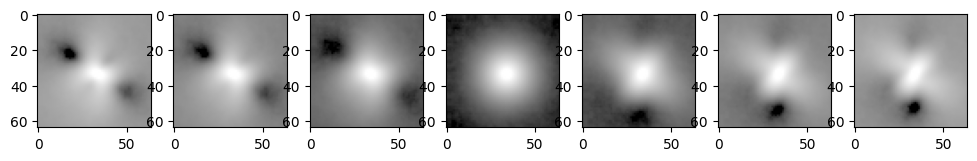

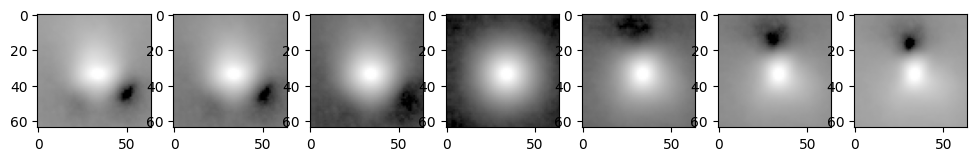

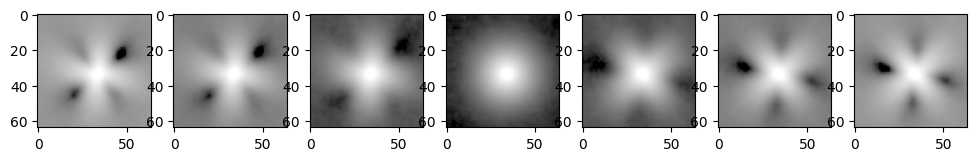

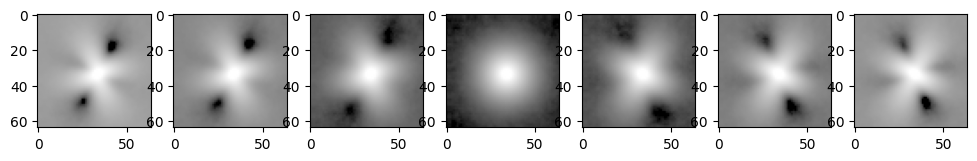

In [19]:
n_pc = 10
n_sigms = 3
std = np.array([S[k]*Vt[k,:].std() for k in range(n_pc)])

for pc in range(n_pc):
  fig, axes = plt.subplots(1, 7, figsize=(12, 30))
  for j, i in enumerate(np.arange(-n_sigms, n_sigms+1, 1)):
    zj = np.zeros(n_pc)
    zj[pc] = i * std[pc]
    x_h = xmean.ravel() + U[:,:n_pc] @ zj
    x_im = x_h.reshape(64,64)
    snorm = SimpleNorm('log', percent=99)
    norm = snorm(x_im)
    axes[j].imshow(x_im, cmap = 'gray', norm=norm)


In [20]:
reconstructed_dataset = reconstruct(U, S, Vt, 4) + xmean

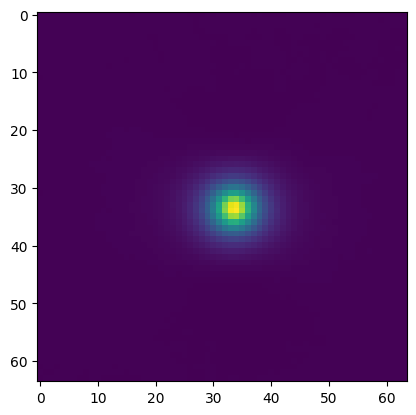

In [21]:
plt.imshow(reconstructed_dataset[:,108].reshape(64,64))

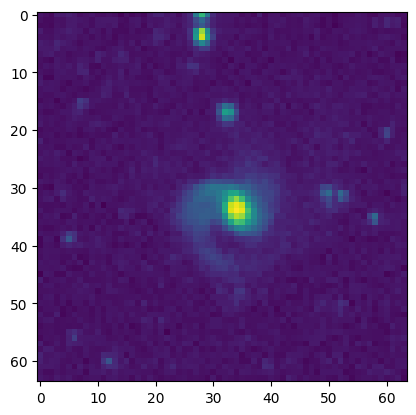

In [22]:
plt.imshow(x[:,108].reshape(64,64))

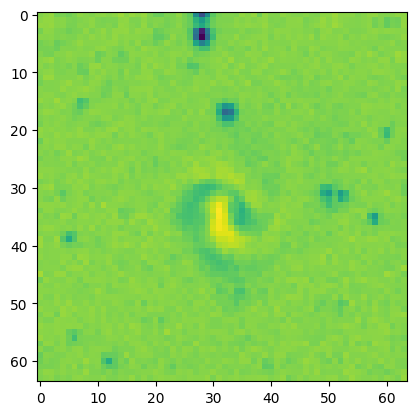

In [23]:
plt.imshow((reconstructed_dataset[:,108]-x[:,108]).reshape(64,64))

In [ ]:
np.sum((reconstructed_dataset[:4]-x[:4])**2)/len(x[:4].flatten())/255.

In [33]:
x[0]

array([39.66666667, 28.33333333, 29.        , ..., 27.        ,
       33.33333333, 26.33333333], shape=(17736,))

In [25]:
x[:,108]

array([32.33333333, 28.66666667, 25.33333333, ..., 31.        ,
       35.66666667, 24.66666667], shape=(4096,))

Task 4


In [26]:
# reproducibility
torch.manual_seed(0)
np.random.seed(0)

# use GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [27]:
N_TRAIN    = int(0.8*len(gray))
BATCH_SIZE = 64

# add channel dim: (N, 1, 64, 64)
x_train = torch.tensor(gray[:N_TRAIN,  None, :, :]/255., dtype=torch.float32)
x_val   = torch.tensor(gray[N_TRAIN:,  None, :, :]/255., dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(x_train, x_train),   # input == target (autoencoder)
    batch_size=BATCH_SIZE, shuffle=True
)


print(f'Training images:   {x_train.shape}')
print(f'Validation images: {x_val.shape}')

Training images:   torch.Size([14188, 1, 64, 64])
Validation images: torch.Size([3548, 1, 64, 64])


In [28]:
class ConvAutoencoder(nn.Module):
    """Convolutional autoencoder for square single-channel images."""

    def __init__(self, channels: int, size: int, latent_dim: int = 4):
        """
        Parameters
        ----------
        channels  : number of input channels (1 for grayscale)
        size      : spatial size of the input image (must be divisible by 8)
        latent_dim: dimension of the bottleneck (latent space)
        """
        super().__init__()
        assert size % 8 == 0, 'image size must be divisible by 8'
        self.latent_dim = latent_dim
        s = size // 8          # spatial size after 3 stride-2 convolutions
        self.s = s
        flat = 128 * s * s     # number of features before the bottleneck Dense

        # --- Encoder ---
        self.enc_conv = nn.Sequential(
            nn.Conv2d(channels, 32,  3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32,       64,  3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64,       128, 3, stride=2, padding=1), nn.ReLU(),
        )
        self.enc_fc = nn.Linear(flat, latent_dim)

        # --- Decoder ---
        self.dec_fc = nn.Linear(latent_dim, flat)
        self.dec_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 128, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(128,  64, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d( 64,  32, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.Conv2d(32, channels, 3, stride=1, padding=1),
            nn.Sigmoid(),   # output in [0, 1] to match normalised pixel values
        )

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """Map an image batch to latent vectors."""
        h = self.enc_conv(x)                      # (N, 128, s, s)
        h = h.view(h.size(0), -1)                 # (N, 128*s*s)  flatten
        return self.enc_fc(h)                      # (N, latent_dim)

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        """Map latent vectors back to images."""
        h = self.dec_fc(z)                         # (N, 128*s*s)
        h = h.view(h.size(0), 128, self.s, self.s) # (N, 128, s, s)  reshape
        return self.dec_conv(h)                    # (N, channels, H, W)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decode(self.encode(x))

In [29]:
LATENT_DIM = 4
SIZE       = 64
CHANNELS   = 1

model = ConvAutoencoder(channels=CHANNELS, size=SIZE, latent_dim=LATENT_DIM).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params:,}')
print(model)

Total trainable parameters: 406,533
ConvAutoencoder(
  (enc_conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (enc_fc): Linear(in_features=8192, out_features=4, bias=True)
  (dec_fc): Linear(in_features=4, out_features=8192, bias=True)
  (dec_conv): Sequential(
    (0): ConvTranspose2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): Sigmoid()
  )
)


In [30]:
EPOCHS = 200

optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn   = nn.MSELoss()

x_val_dev = x_val.to(device)

train_losses = []
val_losses   = []

for epoch in range(1, EPOCHS + 1):
    # --- training ---
    model.train()
    epoch_loss = 0.0
    for x_batch, _ in train_loader:
        x_batch = x_batch.to(device)

        # data augmentation: random horizontal / vertical flip of image to increase training data set
        if torch.rand(1).item() > 0.5:
            x_batch = x_batch.flip(dims=[3])   # horizontal flip
        if torch.rand(1).item() > 0.5:
            x_batch = x_batch.flip(dims=[2])   # vertical flip

        optimizer.zero_grad()
        loss = loss_fn(model(x_batch), x_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * x_batch.size(0)

    epoch_loss /= N_TRAIN
    train_losses.append(epoch_loss)

    # --- validation ---
    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(model(x_val_dev), x_val_dev).item()
    val_losses.append(val_loss)

    if epoch % 20 == 0:
        print(f'Epoch {epoch:3d}/{EPOCHS}  train loss: {epoch_loss:.5f}  val loss: {val_loss:.5f}')

print('Training complete.')

OutOfMemoryError: CUDA out of memory. Tried to allocate 1.73 GiB. GPU 0 has a total capacity of 5.68 GiB of which 1.07 GiB is free. Process 4401 has 1.67 GiB memory in use. Including non-PyTorch memory, this process has 1.53 GiB memory in use. Of the allocated memory 1.05 GiB is allocated by PyTorch, and 340.23 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(train_losses, label='train')
ax.plot(val_losses,   label='validation')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_title(f'CAE training (latent dim = {LATENT_DIM})')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.show()

In [ ]:
N_SHOW = 4

model.eval()
with torch.no_grad():
    recons = model(x_val_dev[:N_SHOW]).cpu().numpy()   # (N_SHOW, 1, 64, 64)

originals = x_val[:N_SHOW].numpy()                     # (N_SHOW, 1, 64, 64)

fig, axes = plt.subplots(2, N_SHOW, figsize=(2.5 * N_SHOW, 5))

row_labels = ['Original', 'Reconstruction']
for row, (imgs, label) in enumerate(zip([originals, recons], row_labels)):
    axes[row, 0].set_ylabel(label, fontsize=11)
    for col in range(N_SHOW):
        axes[row, col].imshow(imgs[col, 0], cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')

plt.suptitle(f'Convolutional autoencoder ﷿﷿﷿ latent dim = {LATENT_DIM}', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
model.eval()
with torch.no_grad():
    z_val = model.encode(x_val_dev).cpu().numpy()   # (20, 4)

print('Latent vectors shape:', z_val.shape)
print('\nPer-dimension statistics:')
print(f'  {"dim":>3}  {"mean":>8}  {"std":>8}  {"min":>8}  {"max":>8}')
for i in range(LATENT_DIM):
    print(f'  {i:>3}  {z_val[:,i].mean():>8.3f}  {z_val[:,i].std():>8.3f}'
          f'  {z_val[:,i].min():>8.3f}  {z_val[:,i].max():>8.3f}')

Task 5


In [ ]:

fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(z_val[:,1], z_val[:,2],c=labels[N_TRAIN:],cmap='tab20b',s=0.5, alpha=0.6)

plt.colorbar(scatter, label='Morphological class')
ax.set_xlabel('Latent 1')
ax.set_ylabel('Latent 2')
ax.set_title('CAE latent space coloured by morphology')


Task 6
